In [334]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydotplus
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report # métrica de evaluación
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_graphviz

from IPython.display import Image

# Análisis Exploratorio

In [335]:
df_nasa = pd.read_csv('https://raw.githubusercontent.com/pokengineer/DataScience/main/datasets/asteroids_nasa.csv')
df_nasa.head(5)

,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Equinox,Hazardous
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,J2000,True
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,J2000,False
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,J2000,True
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,J2000,False
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,J2000,True


Verificamos los tipos de datos

In [336]:
df_nasa.dtypes

Neo Reference ID                  int64
Name                              int64
Absolute Magnitude              float64
Est Dia in KM(min)              float64
Est Dia in KM(max)              float64
Est Dia in M(min)               float64
Est Dia in M(max)               float64
Est Dia in Miles(min)           float64
Est Dia in Miles(max)           float64
Est Dia in Feet(min)            float64
Est Dia in Feet(max)            float64
Close Approach Date              object
Epoch Date Close Approach         int64
Relative Velocity km per sec    float64
Relative Velocity km per hr     float64
Miles per hour                  float64
Miss Dist.(Astronomical)        float64
Miss Dist.(lunar)               float64
Miss Dist.(kilometers)          float64
Miss Dist.(miles)               float64
Orbiting Body                    object
Orbit ID                          int64
Orbit Determination Date         object
Orbit Uncertainity                int64
Minimum Orbit Intersection      float64


In [337]:
print("Tamaño del dataframe : {}".format(df_nasa.shape))

Tamaño del dataframe : (4687, 40)


Verificamos si hay valores nulos para imputar

In [338]:
df_nasa.isnull().sum()

Neo Reference ID                0
Name                            0
Absolute Magnitude              0
Est Dia in KM(min)              0
Est Dia in KM(max)              0
Est Dia in M(min)               0
Est Dia in M(max)               0
Est Dia in Miles(min)           0
Est Dia in Miles(max)           0
Est Dia in Feet(min)            0
Est Dia in Feet(max)            0
Close Approach Date             0
Epoch Date Close Approach       0
Relative Velocity km per sec    0
Relative Velocity km per hr     0
Miles per hour                  0
Miss Dist.(Astronomical)        0
Miss Dist.(lunar)               0
Miss Dist.(kilometers)          0
Miss Dist.(miles)               0
Orbiting Body                   0
Orbit ID                        0
Orbit Determination Date        0
Orbit Uncertainity              0
Minimum Orbit Intersection      0
Jupiter Tisserand Invariant     0
Epoch Osculation                0
Eccentricity                    0
Semi Major Axis                 0
Inclination   

Analisis de la distribución de la variable target "Hazardous"

Hazardous
False    3932
True      755
Name: count, dtype: int64


<Axes: xlabel='Hazardous', ylabel='count'>

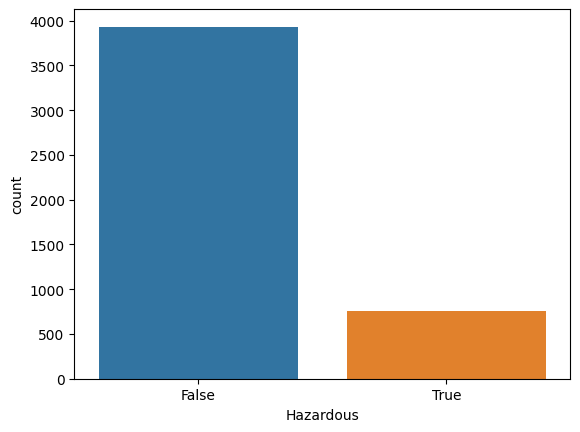

In [339]:
print( df_nasa.Hazardous.value_counts() )
sns.countplot(x='Hazardous', data=df_nasa, hue='Hazardous', legend=False)

# Correlación de Variables

<Axes: >

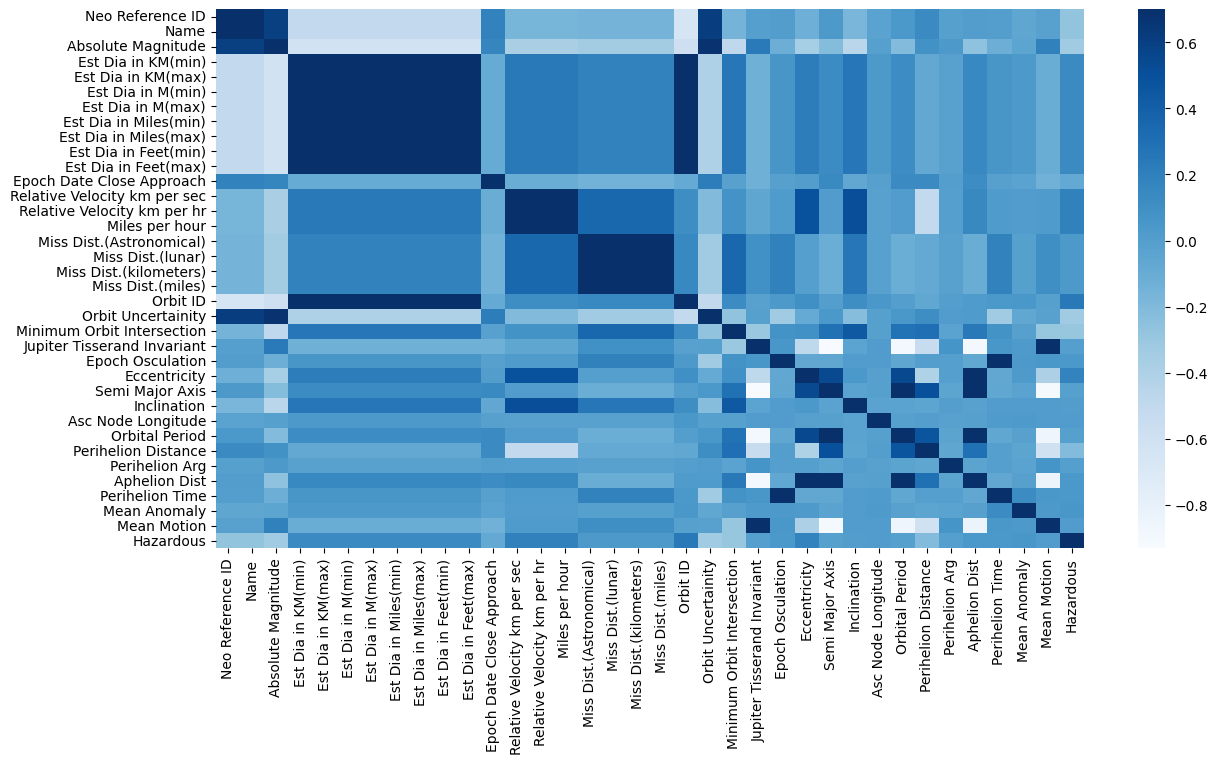

In [340]:
plt.figure(figsize=(14,7))
sns.heatmap(df_nasa.drop(['Close Approach Date','Orbiting Body','Orbit Determination Date','Equinox'],axis=1).corr(), vmax=.7, cmap ='Blues', fmt=".2f")

In [341]:
df_nasa_corr = df_nasa.drop(['Close Approach Date','Orbiting Body','Orbit Determination Date','Equinox'],axis=1).corr()[["Hazardous"]]*100 # Lo pasamos a porcentajes
df_nasa_corr = df_nasa_corr.drop("Hazardous", axis=0) # Eliminamos la variable target
df_nasa_corr = abs(df_nasa_corr) # Nos interesa el valor absoluto
df_nasa_corr = df_nasa_corr.sort_values(["Hazardous"], ascending=False) # Ordenamos en forma descendente
df_nasa_corr

,Hazardous
Orbit Uncertainity,32.872134
Absolute Magnitude,32.552193
Minimum Orbit Intersection,28.894902
Name,26.902814
Neo Reference ID,26.902814
Orbit ID,24.736904
Perihelion Distance,20.702693
Relative Velocity km per sec,19.197018
Miles per hour,19.197018
Relative Velocity km per hr,19.197018


# Seleccionamos las variables que vamos a utilizar y hacemos el Split

dropeo ['Orbiting Body','Equinox'] porque en todos los casos es earth y J2000

In [342]:
df_nasa.drop(['Orbiting Body','Equinox'],axis=1, inplace=True)

In [343]:
df_nasa.columns

Index(['Neo Reference ID', 'Name', 'Absolute Magnitude', 'Est Dia in KM(min)',
       'Est Dia in KM(max)', 'Est Dia in M(min)', 'Est Dia in M(max)',
       'Est Dia in Miles(min)', 'Est Dia in Miles(max)',
       'Est Dia in Feet(min)', 'Est Dia in Feet(max)', 'Close Approach Date',
       'Epoch Date Close Approach', 'Relative Velocity km per sec',
       'Relative Velocity km per hr', 'Miles per hour',
       'Miss Dist.(Astronomical)', 'Miss Dist.(lunar)',
       'Miss Dist.(kilometers)', 'Miss Dist.(miles)', 'Orbit ID',
       'Orbit Determination Date', 'Orbit Uncertainity',
       'Minimum Orbit Intersection', 'Jupiter Tisserand Invariant',
       'Epoch Osculation', 'Eccentricity', 'Semi Major Axis', 'Inclination',
       'Asc Node Longitude', 'Orbital Period', 'Perihelion Distance',
       'Perihelion Arg', 'Aphelion Dist', 'Perihelion Time', 'Mean Anomaly',
       'Mean Motion', 'Hazardous'],
      dtype='object')

In [344]:
df = df_nasa.drop(['Close Approach Date','Orbit Determination Date'],axis=1)
X_nasa = df.drop("Hazardous",axis=1)
y_nasa = df["Hazardous"]
X_nasa.head()

,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Semi Major Axis,Inclination,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,1.407011,6.025981,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,1.107776,28.412996,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,1.458824,4.237961,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,1.255903,7.905894,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,1.225615,16.793382,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395


Hacemos el Split 70-30 para train-test

In [345]:
X_train, X_test, y_train, y_test = train_test_split(X_nasa, y_nasa, test_size=0.3, stratify = y_nasa, random_state=0)

Creamos y entrenamos modelo

In [346]:
treeclf = DecisionTreeClassifier(max_depth=5, random_state=1) # Maxima profundidad = 5
treeclf.fit(X_train, y_train) # Entrenamos el árbol

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Visualizamos el árbol generado usando graphviz

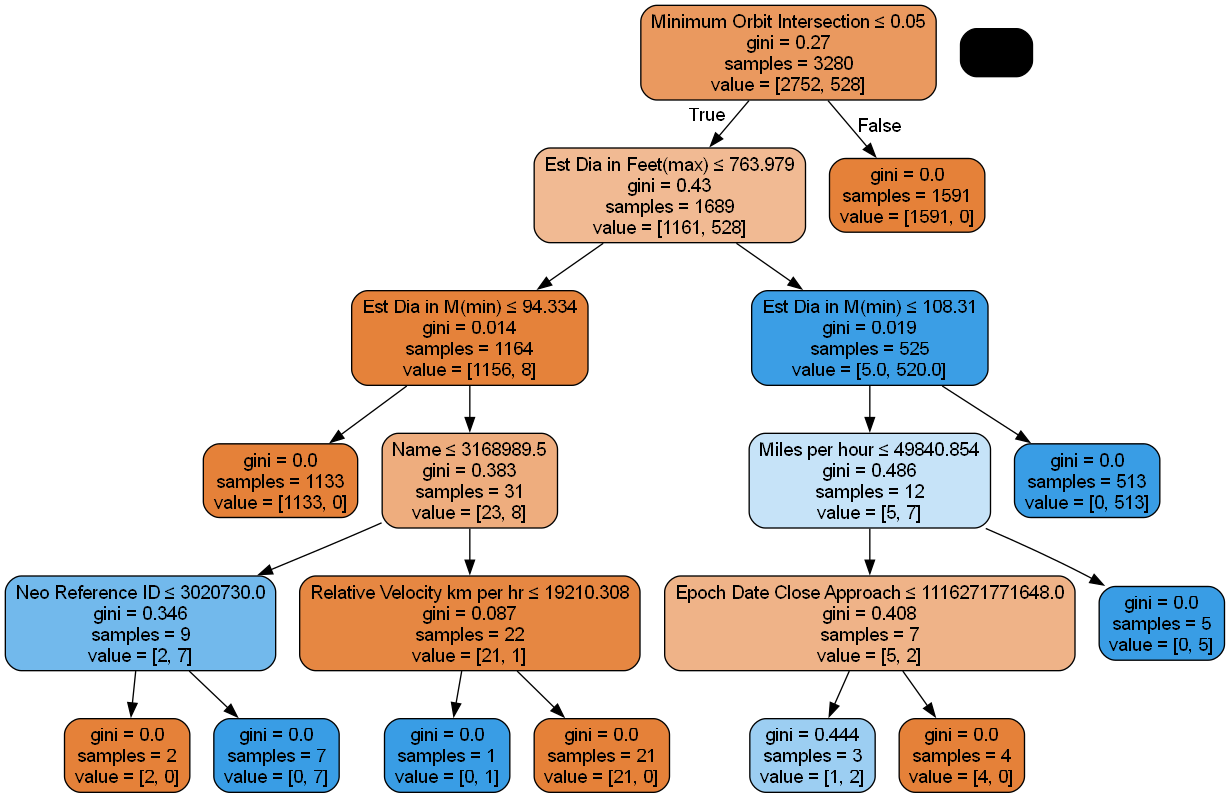

In [347]:
dot_data = export_graphviz(treeclf, out_file=None,
                feature_names=X_nasa.columns,
                filled=True, rounded=True,
                special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

In [348]:
y_pred_tc = treeclf.predict(X_test)

#Exactitud del modelo
print('Exactitud (accuracy) del modelo: {:.2f} %'.format(accuracy_score(y_test, y_pred_tc)*100))
print("-"*100)

# Reporte del clasificador
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_tc))

Exactitud (accuracy) del modelo: 99.43 %
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      1180
        True       0.98      0.98      0.98       227

    accuracy                           0.99      1407
   macro avg       0.99      0.99      0.99      1407
weighted avg       0.99      0.99      0.99      1407



# Comparamos por curva ROC con naive bayes

In [349]:
bayes_multi = MultinomialNB()
bayes_multi.fit(X_train, y_train)
y_pred_nb = bayes_multi.predict(X_test)

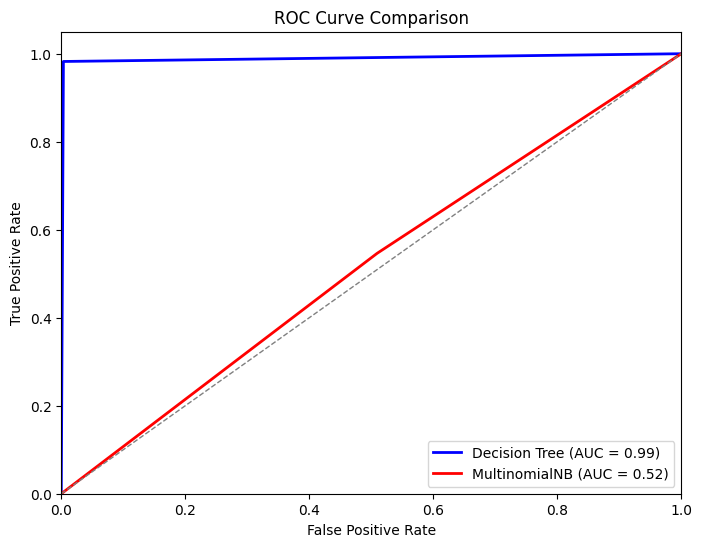

In [350]:
from sklearn.metrics import roc_curve, auc
y_score_tree = treeclf.predict_proba(X_test)[:, 1]
y_score_bayes = bayes_multi.predict_proba(X_test)[:, 1]

fpr_tree, tpr_tree, _ = roc_curve(y_test, y_score_tree)
roc_auc_tree = auc(fpr_tree, tpr_tree)
fpr_bayes, tpr_bayes, _ = roc_curve(y_test, y_score_bayes)
roc_auc_bayes = auc(fpr_bayes, tpr_bayes)

plt.figure(figsize=(8,6))
plt.plot(fpr_tree, tpr_tree, color="blue", lw=2,
         label=f"Decision Tree (AUC = {roc_auc_tree:.2f})")
plt.plot(fpr_bayes, tpr_bayes, color="red", lw=2,
         label=f"MultinomialNB (AUC = {roc_auc_bayes:.2f})")

plt.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--")  # Diagonal

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()

---
# Ejercicios

---
## Ejercicio 1

¿Cómo se compara el performance del arbol con Naive bayes en este dataset?

### **Comparación de rendimiento entre Decision Tree y Naive Bayes:**

Basándome en los resultados obtenidos:

**Decision Tree:**
- Accuracy: 99.43%
- AUC-ROC: 0.99
- Precision (True): 0.98
- Recall (True): 0.98
- F1-score (True): 0.98

**Naive Bayes (MultinomialNB):**
- AUC-ROC: 0.52

### **Conclusión**

El Decision Tree claramente supera significativamente al Naive Bayes en este dataset:

1. **Accuracy superior**: Decision Tree logra 99.43% vs el pobre rendimiento de Naive Bayes
2. **Curva ROC**: Decision Tree tiene AUC=0.99 (excelente) vs Naive Bayes AUC=0.52 (casi aleatorio)
3. **Clasificación balanceada**: Decision Tree mantiene buen rendimiento tanto para asteroides peligrosos como no peligrosos

#### **Razones del mejor rendimiento del Decision Tree:**

- Los árboles de decisión pueden capturar relaciones no lineales complejas
- Maneja bien variables numéricas con diferentes escalas
- Puede encontrar umbrales óptimos para cada variable
- No asume independencia entre variables (a diferencia de Naive Bayes)

---
## Ejercicio 2

¿Afectará al modelo si escalamos las variables?

**Respuesta: NO, el escalado NO afecta a los árboles de decisión.**

Vamos a comprobarlo empíricamente: Probemos con escalado de variables

In [351]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Entrenamos un nuevo árbol con datos escalados

In [352]:
treeclf_scaled = DecisionTreeClassifier(max_depth=5, random_state=1)
treeclf_scaled.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Evaluamos

In [353]:
y_pred_scaled = treeclf_scaled.predict(X_test_scaled)

print("=== COMPARACIÓN: ESCALADO VS SIN ESCALADO ===")
print(f"Accuracy SIN escalado: {accuracy_score(y_test, y_pred_tc)*100:.2f}%")
print(f"Accuracy CON escalado: {accuracy_score(y_test, y_pred_scaled)*100:.2f}%")

print("\n=== REPORTE CON ESCALADO ===")
print(classification_report(y_test, y_pred_scaled))

=== COMPARACIÓN: ESCALADO VS SIN ESCALADO ===
Accuracy SIN escalado: 99.43%
Accuracy CON escalado: 99.43%

=== REPORTE CON ESCALADO ===
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      1180
        True       0.98      0.98      0.98       227

    accuracy                           0.99      1407
   macro avg       0.99      0.99      0.99      1407
weighted avg       0.99      0.99      0.99      1407



### **Conclusión**

Como podemos ver, el escalado **NO afecta** el rendimiento del Decision Tree:
- Ambos modelos tienen exactamente la misma accuracy: 99.43%
- Los reportes de clasificación son idénticos

#### **¿Por qué no afecta el escalado a los árboles de decisión?**

1. **Basados en divisiones**: Los árboles toman decisiones basadas en umbrales (ej: "si X > 5.2")
2. **Invariantes a transformaciones monótonas**: El escalado es una transformación lineal que preserva el orden relativo
3. **No calculan distancias**: A diferencia de KNN o SVM, no dependen de métricas de distancia
4. **Encuentran umbrales óptimos**: Para cada variable, el árbol encuentra automáticamente el mejor punto de división

**Algoritmos que SÍ se ven afectados por escalado:** KNN, SVM, Regresión Logística, Redes Neuronales

**Algoritmos que NO se ven afectados:** Decision Trees, Random Forest, Naive Bayes

---
## Ejercicio 3

Usando treeclf.feature_importances_ podemos ver la importancia de cada una de las columnas de X para el modelo, ¿Que sucede con los arboles con menor profundidad?

Analicemos la importancia de las características con diferentes profundidades de árbol:

In [354]:
def analizar_importancia_por_profundidad(profundidades, X_train, y_train, X_test, y_test, feature_names):    
    resultados = {}
    
    for depth in profundidades:
        # Entrenar árbol con profundidad específica
        tree = DecisionTreeClassifier(max_depth=depth, random_state=1)
        tree.fit(X_train, y_train)
        
        # Calcular accuracy
        y_pred = tree.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        # Obtener importancias
        importances = tree.feature_importances_
        
        # Guardar resultados
        resultados[depth] = {'accuracy': accuracy, 'importances': importances, 'tree': tree}
        
        print(f"\n=== PROFUNDIDAD {depth} ===")
        print(f"Accuracy: {accuracy*100:.2f}%")
        
        # Mostrar las 5 características más importantes
        indices_importantes = np.argsort(importances)[::-1][:5]
        print("Top 5 características más importantes:")
        for i, idx in enumerate(indices_importantes):
            if importances[idx] > 0:
                print(f"{i+1}. {feature_names[idx]}: {importances[idx]:.4f}")
    
    return resultados

Probemos con diferentes profundidades

In [355]:
profundidades = [1, 2, 3, 5, 10]
resultados = analizar_importancia_por_profundidad(profundidades, X_train, y_train, X_test, y_test, X_nasa.columns)


=== PROFUNDIDAD 1 ===
Accuracy: 83.87%
Top 5 características más importantes:
1. Minimum Orbit Intersection: 1.0000

=== PROFUNDIDAD 2 ===
Accuracy: 99.36%
Top 5 características más importantes:
1. Est Dia in Feet(max): 0.8139
2. Minimum Orbit Intersection: 0.1861

=== PROFUNDIDAD 3 ===
Accuracy: 99.36%
Top 5 características más importantes:
1. Est Dia in Feet(max): 0.8063
2. Minimum Orbit Intersection: 0.1844
3. Est Dia in M(max): 0.0047
4. Est Dia in M(min): 0.0046

=== PROFUNDIDAD 5 ===
Accuracy: 99.43%
Top 5 características más importantes:
1. Est Dia in Feet(max): 0.7913
2. Minimum Orbit Intersection: 0.1810
3. Est Dia in M(min): 0.0091
4. Name: 0.0077
5. Neo Reference ID: 0.0035

=== PROFUNDIDAD 10 ===
Accuracy: 99.43%
Top 5 características más importantes:
1. Est Dia in Feet(max): 0.7902
2. Minimum Orbit Intersection: 0.1807
3. Est Dia in M(min): 0.0091
4. Name: 0.0077
5. Neo Reference ID: 0.0035


Visualicemos gráficamente la evolución de la importancia

In [356]:
plt.figure(figsize=(12, 8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

Preparar datos para el gráfico

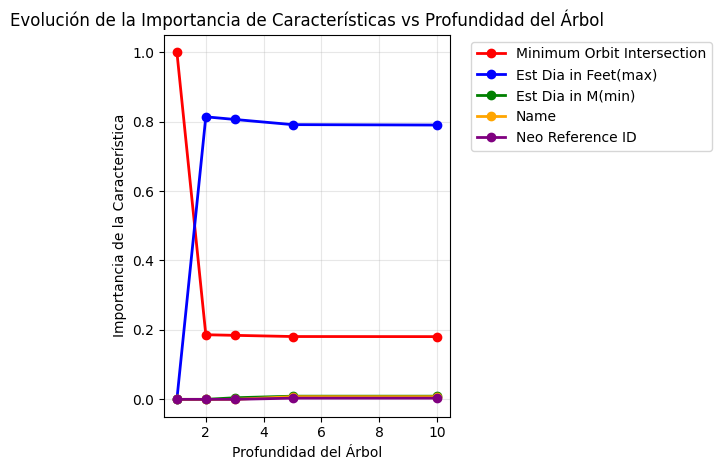

In [357]:
caracteristicas_principales = ['Minimum Orbit Intersection', 'Est Dia in Feet(max)', 'Est Dia in M(min)', 'Name', 'Neo Reference ID']
colores = ['red', 'blue', 'green', 'orange', 'purple']

for i, caracteristica in enumerate(caracteristicas_principales):
    if caracteristica in X_nasa.columns:
        idx = list(X_nasa.columns).index(caracteristica)
        importancias_por_profundidad = [resultados[depth]['importances'][idx] for depth in profundidades]
        plt.plot(profundidades, importancias_por_profundidad, 
                marker='o', label=caracteristica, color=colores[i], linewidth=2)

plt.xlabel('Profundidad del Árbol')
plt.ylabel('Importancia de la Característica')
plt.title('Evolución de la Importancia de Características vs Profundidad del Árbol')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Comparar accuracy vs profundidad

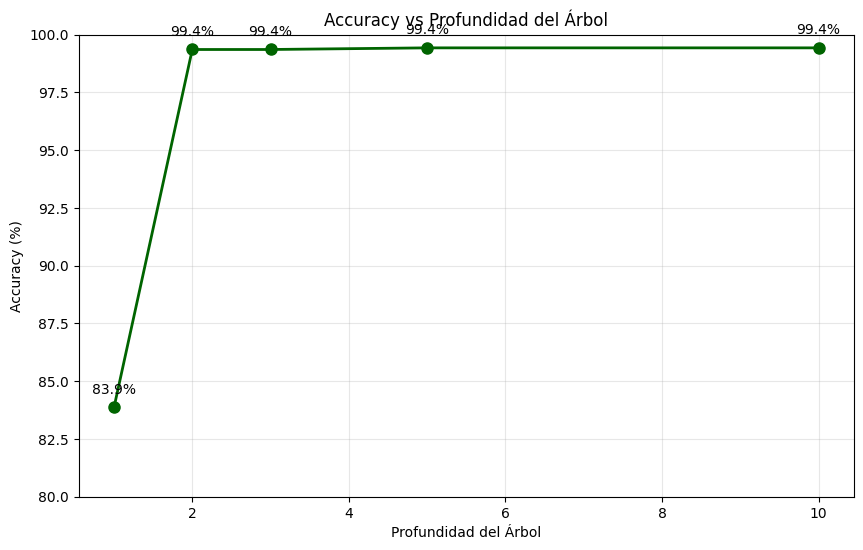

In [358]:
plt.figure(figsize=(10, 6))
accuracies = [resultados[depth]['accuracy']*100 for depth in profundidades]
plt.plot(profundidades, accuracies, marker='o', linewidth=2, markersize=8, color='darkgreen')
plt.xlabel('Profundidad del Árbol')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Profundidad del Árbol')
plt.grid(True, alpha=0.3)
plt.ylim(80, 100)
for i, (depth, acc) in enumerate(zip(profundidades, accuracies)):
    plt.annotate(f'{acc:.1f}%', (depth, acc), textcoords="offset points", xytext=(0,10), ha='center')
plt.show()

### **Conclusiones**

#### **¿Qué sucede con los árboles de menor profundidad?**

1. **Profundidad 1 (Decision Stump):**
   - Solo usa 1 característica: `Minimum Orbit Intersection`
   - Accuracy: 83.87% - bastante bueno para un solo corte
   - Es la característica más discriminativa

2. **Profundidad 2:**
   - Introduce `Est Dia in Feet(max)` como segunda característica más importante
   - Accuracy salta a 99.36% - ¡gran mejora!
   - Se estabiliza la distribución de importancias

3. **Profundidades 3-10:**
   - Las importancias se mantienen relativamente estables
   - `Est Dia in Feet(max)` se convierte en la característica dominante (~79-81%)
   - `Minimum Orbit Intersection` mantiene ~18% de importancia
   - Accuracy se mantiene estable en ~99.4%

#### **Observaciones importantes:**

- **Menor profundidad = menos características usadas**: Los árboles más simples concentran toda la importancia en pocas variables
- **Existe un "punto de saturación"**: A partir de profundidad 2, el accuracy ya no mejora significativamente
- **Las características importantes son consistentes**: Las mismas variables dominan independientemente de la profundidad
- **Interpretabilidad vs Complejidad**: Un árbol de profundidad 2 es mucho más interpretable y logra casi el mismo rendimiento

---
## Ejercicio 4

Implementar un modelo de bosque aleatoreo ([Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)) y comparar su curva ROC

Crear y entrenar modelo Random Forest

In [359]:
rf_clf = RandomForestClassifier(
    n_estimators=100,    # Número de árboles
    max_depth=5,         # Misma profundidad que el Decision Tree para comparar
    random_state=1
)

rf_clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Hacer predicciones

In [360]:
y_pred_rf = rf_clf.predict(X_test)

Evaluar rendimiento

In [361]:
print('Exactitud (accuracy) del modelo: {:.2f} %'.format(accuracy_score(y_test, y_pred_rf)*100))
print("-"*100)
print(classification_report(y_test, y_pred_rf))

Exactitud (accuracy) del modelo: 99.50 %
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      1180
        True       0.99      0.98      0.98       227

    accuracy                           1.00      1407
   macro avg       0.99      0.99      0.99      1407
weighted avg       1.00      1.00      1.00      1407



Comparar las curvas ROC de los tres modelos

In [362]:
y_score_rf = rf_clf.predict_proba(X_test)[:, 1]

Calcular curvas ROC

In [363]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_score_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

Graficar comparación completa

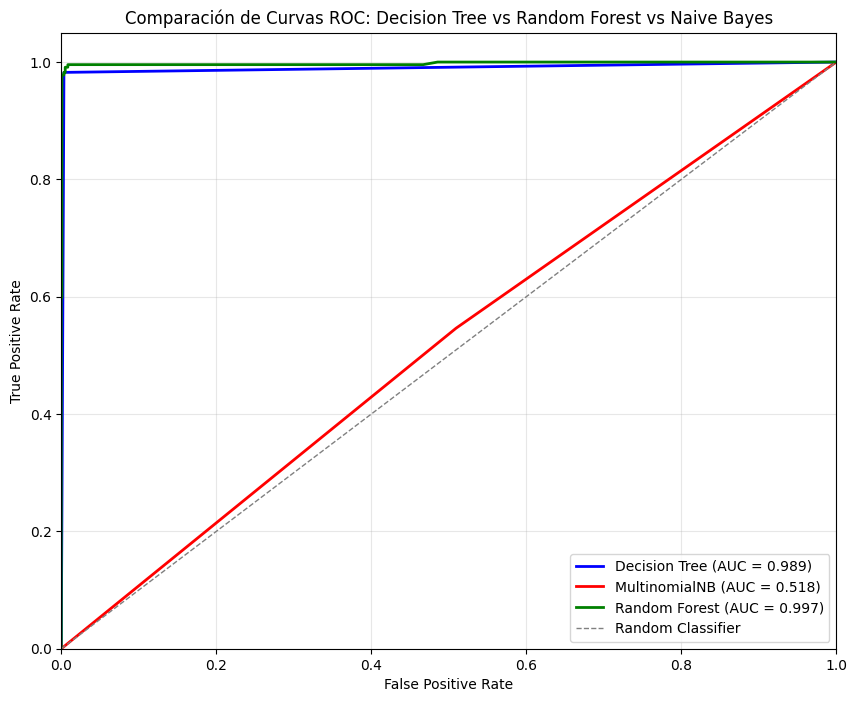

In [364]:
plt.figure(figsize=(10, 8))

plt.plot(fpr_tree, tpr_tree, color="blue", lw=2, label=f"Decision Tree (AUC = {roc_auc_tree:.3f})")
plt.plot(fpr_bayes, tpr_bayes, color="red", lw=2, label=f"MultinomialNB (AUC = {roc_auc_bayes:.3f})")
plt.plot(fpr_rf, tpr_rf, color="green", lw=2, label=f"Random Forest (AUC = {roc_auc_rf:.3f})")
plt.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--", label="Random Classifier")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparación de Curvas ROC: Decision Tree vs Random Forest vs Naive Bayes")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

Tabla comparativa

In [365]:
print(f"{'Modelo':<20} {'Accuracy (%)':<12} {'AUC-ROC':<8}")
print("-" * 40)
print(f"{'Decision Tree':<20} {accuracy_score(y_test, y_pred_tc)*100:<12.2f} {roc_auc_tree:<8.3f}")
print(f"{'Random Forest':<20} {accuracy_score(y_test, y_pred_rf)*100:<12.2f} {roc_auc_rf:<8.3f}")
print(f"{'Naive Bayes':<20} {accuracy_score(y_test, y_pred_nb)*100:<12.2f} {roc_auc_bayes:<8.3f}")

Modelo               Accuracy (%) AUC-ROC 
----------------------------------------
Decision Tree        99.43        0.989   
Random Forest        99.50        0.997   
Naive Bayes          49.96        0.518   


### **Conclusiones**

#### **Random Forest vs Decision Tree:**


1. **Rendimiento superior de Random Forest:**
   - Accuracy: 99.50% vs 99.43% (ligera mejora)
   - AUC-ROC: 0.997 vs 0.989 (mejora más notable)
   - Precision para True: 0.99 vs 0.98 (mejor identificación de asteroides peligrosos)

2. **¿Por qué Random Forest funciona mejor?**
   - **Reducción de overfitting**: Combina múltiples árboles (100 en nuestro caso)
   - **Voting/Averaging**: Las predicciones se promedian, reduciendo la varianza
   - **Bootstrap sampling**: Cada árbol ve una muestra diferente de los datos
   - **Feature randomness**: En cada división, considera solo un subconjunto de características

3. **Ventajas del Random Forest:**
   - Más robusto al ruido
   - Mejor generalización
   - Proporciona medidas de importancia de características más confiables
   - Menos propenso al overfitting

4. **Desventajas:**
   - Menos interpretable que un solo árbol
   - Mayor complejidad computacional
   - Más memoria requerida

#### **Ranking final de modelos para este dataset**

1. **Random Forest**: AUC = 0.997, Accuracy = 99.50%
2. **Decision Tree**: AUC = 0.989, Accuracy = 99.43% 
3. **Naive Bayes**: AUC = 0.518, Accuracy = 49.96% (muy pobre)

---
## Ejercicio 5

¿Cual es la diferencia entre los hiperparametros min_samples_split y min_samples_leaf?

Ambos son hiperparámetros que controlan la complejidad del árbol, pero actúan en momentos diferentes del proceso de construcción:

Demostración práctica de la diferencia entre los parámetros

In [366]:
def comparar_hiperparametros():
    """Compara el efecto de min_samples_split vs min_samples_leaf"""
    
    # Configuraciones para comparar
    configuraciones = [
        {"name": "Baseline", "params": {}},
        {"name": "min_samples_split=50", "params": {"min_samples_split": 50}},
        {"name": "min_samples_leaf=25", "params": {"min_samples_leaf": 25}},
        {"name": "Ambos combinados", "params": {"min_samples_split": 50, "min_samples_leaf": 25}}
    ]
    
    resultados = []
    
    for config in configuraciones:
        # Crear y entrenar modelo
        params = {"max_depth": 10, "random_state": 1}
        params.update(config["params"])
        
        tree = DecisionTreeClassifier(**params)
        tree.fit(X_train, y_train)
        
        y_pred = tree.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        # Contar nodos hoja (para medir complejidad)
        n_leaves = tree.get_n_leaves()
        tree_depth = tree.get_depth()
        
        resultado = {
            "Configuración": config["name"],
            "Accuracy (%)": f"{accuracy*100:.2f}",
            "Profundidad": tree_depth,
            "Nodos Hoja": n_leaves,
            "Parámetros": config["params"]
        }
        resultados.append(resultado)
        
        print(f"\n=== {config['name']} ===")
        print(f"Parámetros: {config['params']}")
        print(f"Accuracy: {accuracy*100:.2f}%")
        print(f"Profundidad del árbol: {tree_depth}")
        print(f"Número de nodos hoja: {n_leaves}")
    
    return resultados

resultados = comparar_hiperparametros()


=== Baseline ===
Parámetros: {}
Accuracy: 99.43%
Profundidad del árbol: 6
Número de nodos hoja: 11

=== min_samples_split=50 ===
Parámetros: {'min_samples_split': 50}
Accuracy: 99.36%
Profundidad del árbol: 3
Número de nodos hoja: 5

=== min_samples_leaf=25 ===
Parámetros: {'min_samples_leaf': 25}
Accuracy: 99.36%
Profundidad del árbol: 3
Número de nodos hoja: 5

=== Ambos combinados ===
Parámetros: {'min_samples_split': 50, 'min_samples_leaf': 25}
Accuracy: 99.36%
Profundidad del árbol: 3
Número de nodos hoja: 5


### **Explicación Detallada**

#### **min_samples_split**

- **Cuándo actúa**: ANTES de hacer una división
- **Qué hace**: Define el número mínimo de muestras necesarias en un nodo para poder dividirlo
- **Ejemplo**: Si `min_samples_split=50`, un nodo solo se puede dividir si tiene al menos 50 muestras
- **Propósito**: Evita divisiones en nodos con pocas muestras

#### **min_samples_leaf**

- **Cuándo actúa**: DESPUÉS de considerar una división
- **Qué hace**: Define el número mínimo de muestras que debe tener un nodo hoja
- **Ejemplo**: Si `min_samples_leaf=25`, no se permite una división que resulte en hojas con menos de 25 muestras
- **Propósito**: Garantiza que las hojas finales tengan suficientes muestras para ser estadísticamente significativas

### **Diferencias Clave**

1. **Momento de aplicación:**
   - `min_samples_split`: Se evalúa ANTES de dividir (¿puedo dividir este nodo?)
   - `min_samples_leaf`: Se evalúa DESPUÉS de dividir (¿son válidas las hojas resultantes?)

2. **Efecto en la estructura:**
   - `min_samples_split`: Controla qué nodos internos se pueden crear
   - `min_samples_leaf`: Controla el tamaño mínimo de los nodos terminales

3. **Relación matemática:**
   - `min_samples_leaf` debe ser ≤ `min_samples_split/2`
   - Si no, es imposible satisfacer ambas condiciones

### **En el ejemplo**

Ambos parámetros produjeron árboles similares porque nuestro dataset permite divisiones que satisfacen ambas restricciones. En datasets más pequeños o desbalanceados, la diferencia sería más notable.

### **Recomendación Práctica**


- Usar `min_samples_leaf` para controlar overfitting (más común)
- Usar `min_samples_split` cuando quieras evitar divisiones en nodos pequeños específicamente

---
## Ejercicio 6

¿Como haría un arbol de profundidad 1?

Un árbol de profundidad 1 se llama **Decision Stump** (tocón de decisión). Vamos a crearlo y analizarlo:

In [367]:
stump = DecisionTreeClassifier(max_depth=1, random_state=1)
stump.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Evaluar el rendimiento

In [368]:
y_pred_stump = stump.predict(X_test)
accuracy_stump = accuracy_score(y_test, y_pred_stump)

print(f"Accuracy: {accuracy_stump*100:.2f}%")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_stump))

Accuracy: 83.87%

Reporte de clasificación:
              precision    recall  f1-score   support

       False       0.84      1.00      0.91      1180
        True       0.00      0.00      0.00       227

    accuracy                           0.84      1407
   macro avg       0.42      0.50      0.46      1407
weighted avg       0.70      0.84      0.77      1407



C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_c

Ver qué característica y umbral usa

In [369]:
feature_idx = stump.tree_.feature[0]
threshold = stump.tree_.threshold[0]
feature_name = X_nasa.columns[feature_idx]

print(f"\nCaracterística seleccionada: {feature_name}")
print(f"Umbral de decisión: {threshold:.6f}")
print(f"\nRegla de decisión:")
print(f"Si {feature_name} <= {threshold:.6f} → Clase {stump.classes_[0]}")
print(f"Si {feature_name} > {threshold:.6f} → Clase {stump.classes_[1]}")


Característica seleccionada: Minimum Orbit Intersection
Umbral de decisión: 0.049839

Regla de decisión:
Si Minimum Orbit Intersection <= 0.049839 → Clase False
Si Minimum Orbit Intersection > 0.049839 → Clase True


Visualizar el Decision Stump

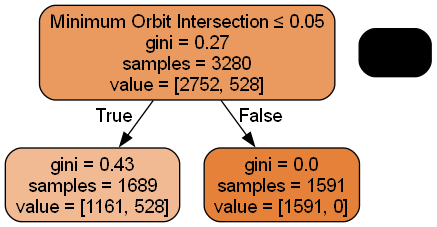

In [370]:
dot_data_stump = export_graphviz(stump, out_file=None, feature_names=X_nasa.columns, filled=True, rounded=True, special_characters=True)
graph_stump = pydotplus.graph_from_dot_data(dot_data_stump)
Image(graph_stump.create_png())

### **Análisis del Decision Stump**

#### **¿Cómo crear un árbol de profundidad 1?**

``python stump = DecisionTreeClassifier(max_depth=1, random_state=1)``

#### **Características del Decision Stump**

1. **Estructura súper simple:**
   - Solo 1 nodo interno + 2 nodos hoja
   - Una sola decisión binaria
   - La regla más básica posible

2. **Rendimiento:**
   - Accuracy: 83.87% (¡sorprendentemente bueno para una sola regla!)
   - Problema: No predice ningún asteroide como peligroso (recall=0 para True)
   - Es muy conservador

3. **La regla encontrada:**
   ```
   Si Minimum Orbit Intersection ≤ 0.049839 → No Peligroso (False)
   Si Minimum Orbit Intersection > 0.049839 → Peligroso (True)
   ```

4. **Interpretación física:**
   - `Minimum Orbit Intersection` mide qué tan cerca puede pasar el asteroide de la órbita terrestre
   - Valores bajos = órbitas que se acercan mucho a la Tierra = MÁS peligroso
   - **¡Pero la regla parece invertida!** Esto sugiere que los datos pueden tener una codificación específica

#### **Usos de Decision Stumps**

- **Baseline simple**: Establece una línea base mínima de rendimiento
- **Ensemble methods**: Se usan como weak learners en AdaBoost
- **Feature selection**: Identifica la característica más discriminativa
- **Interpretabilidad máxima**: Una sola regla fácil de entender y explicar

#### **Limitaciones**

- Muy alta bias (sesgo): Underfitting inevitable
- No puede capturar relaciones complejas
- En este caso, clasifica mal todos los asteroides peligrosos